In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from typing import Any, List

: 

In [2]:
oae = xr.open_dataset("c:\\Users\\junsu\\my_project\\data\\oae_ensembles.nc")
oae_df = oae.to_dataframe()
oae_df = oae_df.reset_index().pivot(
    index="time_elapsed", columns=["release_year", "polygon", "release_month"], values="OAE_efficiency"
)
oae_df.index += 1
oae_df.dropna(axis=1, how="all", inplace=True)
oae_diffed = oae_df - oae_df.shift().fillna(0)

In [18]:
oae_df.columns.get_level_values(1).unique()

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       680, 681, 682, 683, 684, 685, 686, 687, 688, 689],
      dtype='int64', name='polygon', length=690)

<Axes: xlabel='time_elapsed'>

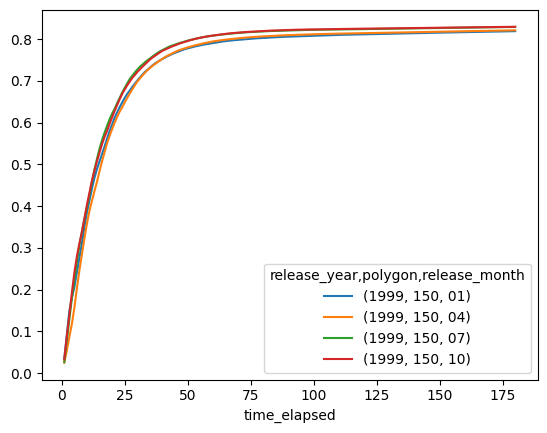

In [23]:
oae_df.loc[:, oae_df.columns.get_level_values(1) == 150].plot()

# Data

N_month
1      0.028776
2      0.042606
3      0.052881
4      0.043742
5      0.036604
         ...   
176    0.000080
177    0.000256
178    0.000665
179    0.000088
180    0.000247
Length: 180, dtype: float64

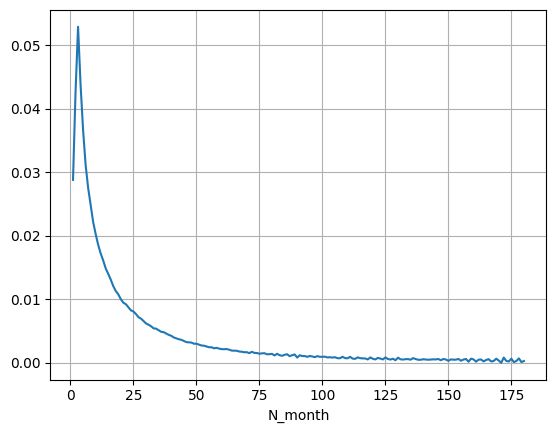

In [5]:
oae_diffed.mean(axis=1).plot(legend=False, grid=True)
oae_diffed.mean(axis=1)

np.float64(3.8167835855986376)

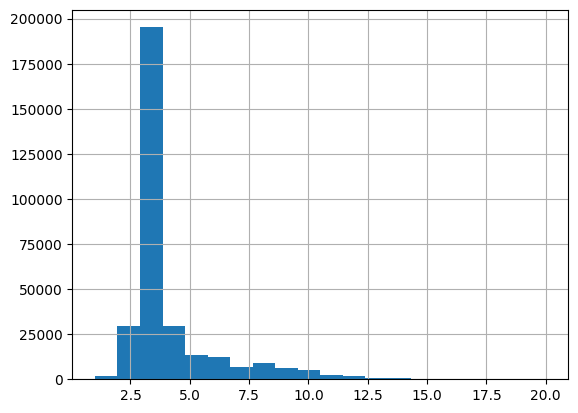

In [6]:
oae_diffed.idxmax(axis=0).hist(bins=20, grid=True)
oae_diffed.idxmax(axis=0).mean()

In [7]:
def shift_cols_max_to_top(df: pd.DataFrame) -> pd.DataFrame:
    arr = df.values.astype(float)
    n_rows, _ = arr.shape

    # 1) Compute shifts: row-index of max in each column
    shifts = arr.argmax(axis=0)             # shape (n_cols,)

    # 2) Build source_row via broadcasting
    rows = np.arange(n_rows)[:, None]       # shape (n_rows, 1)
    source_row = rows + shifts[None, :]     # shape (n_rows, n_cols)

    # 3) Prepare output full of NaNs
    result = np.full_like(arr, np.nan, dtype=float)

    # 4) Mask valid positions
    valid = source_row < n_rows

    # 5) Extract valid coordinate pairs
    i, j = np.nonzero(valid)

    # 6) Fill only valid positions
    result[i, j] = arr[source_row[i, j], j]

    # Return as DataFrame with original index/columns
    return pd.DataFrame(result, index=df.index, columns=df.columns)

In [8]:
shifted_oae_diffed = shift_cols_max_to_top(oae_diffed)

In [23]:
def partition_sorted_values_by_count(values: pd.Index, n_buckets: int) -> List[List[Any]]:
    """
    Partition unique values into n buckets such that:
    - Each bucket contains unique values in sorted order.
    - The total count of values (frequency) in each bucket is approximately equal.
    - The buckets are ordered: all values in bucket[i] < values in bucket[i+1].

    :param values: A pandas Index containing values (e.g., from df.columns.get_level_values(0)).
    :param n_buckets: Number of buckets to split the values into.
    :return: A list of n lists, where each list contains unique values assigned to that bucket.
    """
    value_counts = values.value_counts()
    sorted_values = sorted(value_counts.index)
    items = [(val, value_counts[val]) for val in sorted_values]

    total = sum(count for _, count in items)
    target = total / n_buckets

    buckets = []
    current_bucket = []
    current_sum = 0

    for val, count in items:
        if current_sum + count > target and len(buckets) < n_buckets - 1:
            buckets.append(current_bucket)
            current_bucket = []
            current_sum = 0
        current_bucket.append(val)
        current_sum += count

    buckets.append(current_bucket)

    print("Bucket summary:")
    for i, bucket in enumerate(buckets):
        bucket_count = sum(value_counts[val] for val in bucket)
        print(f"Bucket {i+1}: {bucket} (total count: {bucket_count})")
    return buckets

In [30]:
lat_bucket_num = 10
lat_buckets = partition_sorted_values_by_count(shifted_oae_diffed.columns.get_level_values(0), lat_bucket_num)

Bucket summary:
Bucket 1: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38] (total count: 30240)
Bucket 2: [39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62] (total count: 30324)
Bucket 3: [63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88] (total count: 31012)
Bucket 4: [89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119] (total count: 30612)
Bucket 5: [120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150] (total count: 31088)
Bucket 6: [151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182] (total count: 

## Empirical Analysis

In [26]:
truncate = 4
total_lat_number = len(shifted_oae_diffed.columns.get_level_values(0).unique())

month_tuple = ("January", "April", "July", "October")

acf_term_structure = dict(
    total= np.zeros((len(shifted_oae_diffed) - truncate)),
)
acf_term_structure.update(
    {month.lower(): np.zeros((len(shifted_oae_diffed) - truncate)) for month in month_tuple}
)
acf_term_structure.update(
    {f"lat_{np.mean(lat_bucket)}": np.zeros((len(shifted_oae_diffed) - truncate)) for lat_bucket in lat_buckets}
)
acf_term_structure.update(
    {month.lower() + f"_lat_{np.mean(lat_bucket)}": np.zeros((len(shifted_oae_diffed) - truncate)) for month in month_tuple for lat_bucket in lat_buckets}
)

r_sq_term_structure = {
    k: np.zeros((len(shifted_oae_diffed) - truncate)) for k in acf_term_structure.keys()
}
tss_term_structure = {
    k: np.zeros((len(shifted_oae_diffed) - truncate)) for k in acf_term_structure.keys()
}

np.zeros((len(shifted_oae_diffed) - truncate))

lat_idx = shifted_oae_diffed.columns.get_level_values(0)
for i in range(len(shifted_oae_diffed) - truncate):
    ar1_model = sm.OLS(shifted_oae_diffed.iloc[i+1], shifted_oae_diffed.iloc[i], missing="drop")
    ar1_model_fitted: sm.regression.linear_model.RegressionResults = ar1_model.fit()
    acf_term_structure["total"][i] = ar1_model_fitted.params.values[0]
    tss_term_structure["total"][i] = ar1_model_fitted.model.endog.var()
    r_sq_term_structure["total"][i] = ar1_model_fitted.rsquared
    for month in month_tuple:
        col = shifted_oae_diffed.columns.get_level_values(2).str.contains(month)
        ar1_model = sm.OLS(
            shifted_oae_diffed.iloc[i+1, col],
            shifted_oae_diffed.iloc[i, col],
            missing="drop",
        )
        ar1_model_fitted: sm.regression.linear_model.RegressionResults = ar1_model.fit()
        acf_term_structure[month.lower()][i] = ar1_model_fitted.params.values[0]
        tss_term_structure[month.lower()][i] = ar1_model_fitted.model.endog.var()
        r_sq_term_structure[month.lower()][i] = ar1_model_fitted.rsquared
    for lat_bucket in lat_buckets:
        avg_lat = np.mean(lat_bucket)
        col = (lat_bucket[0] <= lat_idx) & (lat_idx <= lat_bucket[-1])
        ar1_model = sm.OLS(
            shifted_oae_diffed.iloc[i+1, col],
            shifted_oae_diffed.iloc[i, col],
            missing="drop",
        )
        ar1_model_fitted: sm.regression.linear_model.RegressionResults = ar1_model.fit()
        acf_term_structure[f"lat_{avg_lat}"][i] = ar1_model_fitted.params.values[0]
        tss_term_structure[f"lat_{avg_lat}"][i] = ar1_model_fitted.model.endog.var()
        r_sq_term_structure[f"lat_{avg_lat}"][i] = ar1_model_fitted.rsquared
    for month in month_tuple:
        for lat_bucket in lat_buckets:
            avg_lat = np.mean(lat_bucket)
            col = (lat_bucket[0] <= lat_idx) & (lat_idx <= lat_bucket[-1])
            col2 = shifted_oae_diffed.columns.get_level_values(2).str.contains(month)
            ar1_model = sm.OLS(
                shifted_oae_diffed.iloc[i+1, col & col2],
                shifted_oae_diffed.iloc[i, col & col2],
                missing="drop",
            )
            ar1_model_fitted: sm.regression.linear_model.RegressionResults = ar1_model.fit()
            acf_term_structure[f"{month.lower()}_lat_{avg_lat}"][i] = ar1_model_fitted.params.values[0]
            tss_term_structure[f"{month.lower()}_lat_{avg_lat}"][i] = ar1_model_fitted.model.endog.var()
            r_sq_term_structure[f"{month.lower()}_lat_{avg_lat}"][i] = ar1_model_fitted.rsquared
acf_term_structure_df = pd.DataFrame(acf_term_structure)
r_sq_term_structure_df = pd.DataFrame(r_sq_term_structure)
tss_term_structure_df = pd.DataFrame(tss_term_structure)

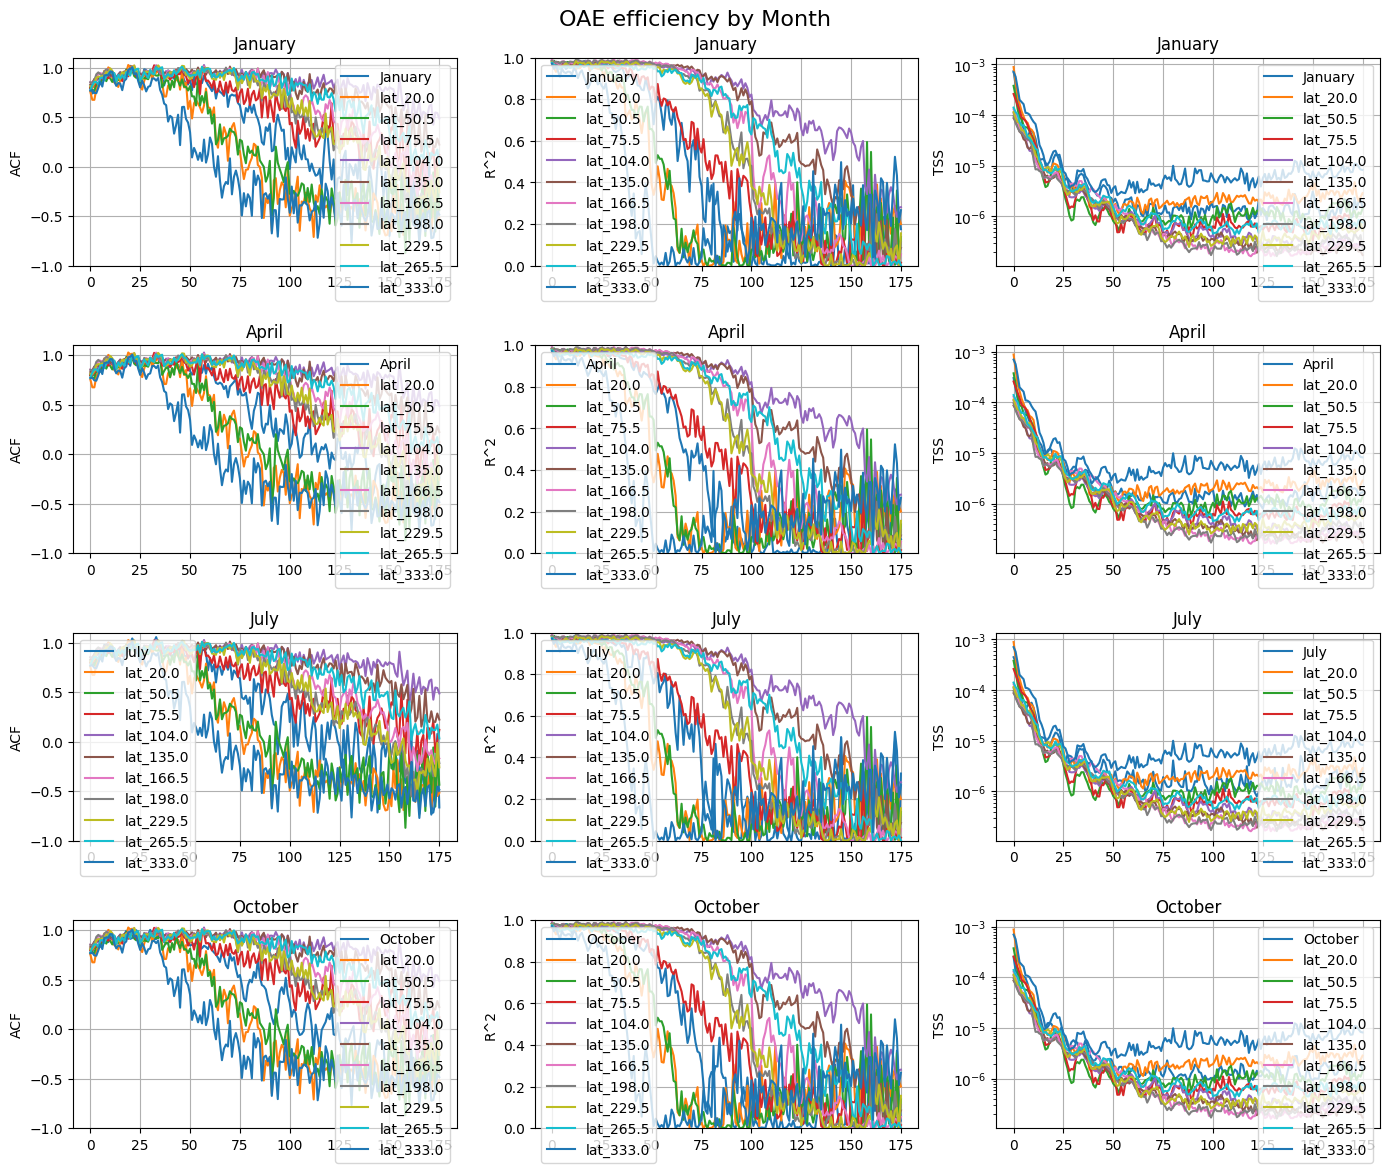

In [33]:
fig, ax = plt.subplots(4, 3, figsize=(14, 12))
fig.suptitle("OAE efficiency by Month", fontsize=16)

for i, month in enumerate(month_tuple):
    ax[i, 0].plot(acf_term_structure_df[month.lower()], label=month)
    ax[i, 0].set_title(month)
    ax[i, 0].grid(True)
    ax[i, 0].set_ylim(-1, 1.1)
    ax[i, 0].set_ylabel("ACF")
    ax[i, 1].plot(r_sq_term_structure_df[month.lower()], label=month)
    ax[i, 1].set_title(month)
    ax[i, 1].grid(True)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_ylabel("R^2")
    ax[i, 2].plot(tss_term_structure_df[month.lower()], label=month)
    ax[i, 2].set_title(month)
    ax[i, 2].grid(True)
    ax[i, 2].set_ylabel("TSS")
    for lat_bucket in lat_buckets:
        avg_lat = np.mean(lat_bucket)   
        ax[i, 0].plot(acf_term_structure_df[f"lat_{avg_lat}"], label=f"lat_{avg_lat}")
        ax[i, 1].plot(r_sq_term_structure_df[f"lat_{avg_lat}"], label=f"lat_{avg_lat}")
        ax[i, 2].plot(tss_term_structure_df[f"lat_{avg_lat}"], label=f"lat_{avg_lat}")
for i in range(4):
    ax[i, 2].set_yscale("log")
    ax[i, 0].legend()
    ax[i, 1].legend()
    ax[i, 2].legend()
plt.tight_layout()
plt.show()

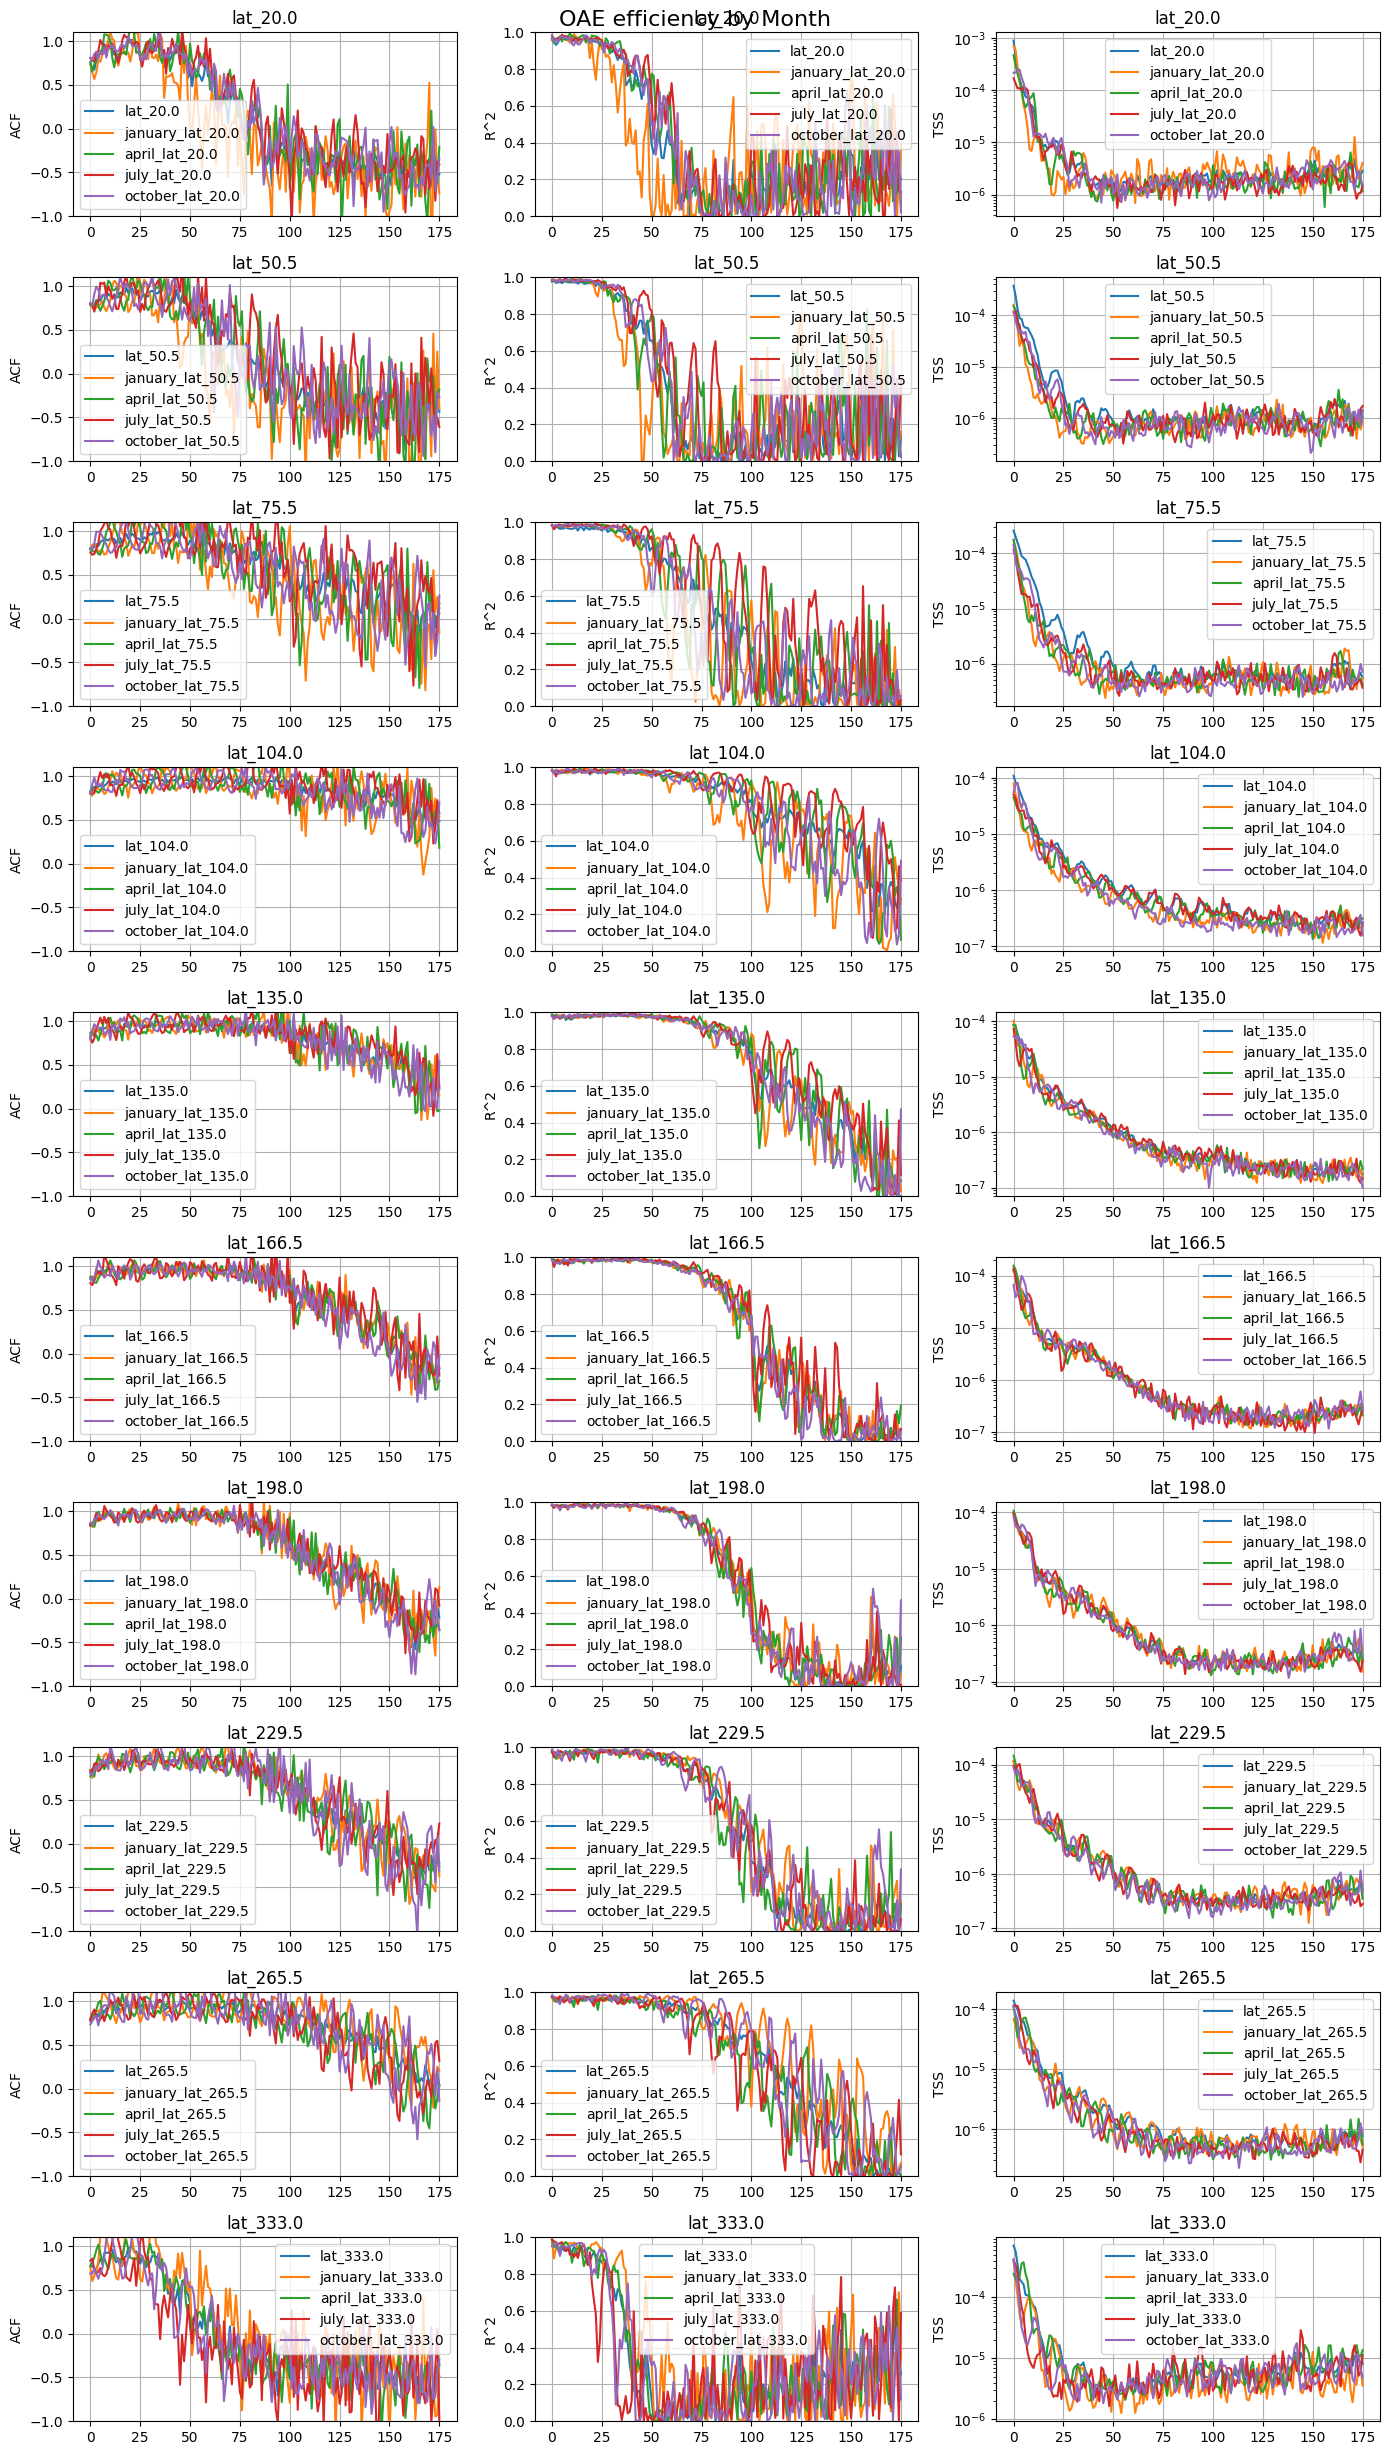

In [34]:
fig, ax = plt.subplots(lat_bucket_num, 3, figsize=(14, 25))
fig.suptitle("OAE efficiency by Month", fontsize=16)

for i, lat_bucket in enumerate(lat_buckets):
    avg_lat = np.mean(lat_bucket)
    ax[i, 0].plot(acf_term_structure_df[f"lat_{avg_lat}"], label=f"lat_{avg_lat}")
    ax[i, 0].set_title(f"lat_{avg_lat}")
    ax[i, 0].grid(True)
    ax[i, 0].set_ylim(-1, 1.1)
    ax[i, 0].set_ylabel("ACF")
    ax[i, 1].plot(r_sq_term_structure_df[f"lat_{avg_lat}"], label=f"lat_{avg_lat}")
    ax[i, 1].set_title(f"lat_{avg_lat}")
    ax[i, 1].grid(True)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_ylabel("R^2")
    ax[i, 2].plot(tss_term_structure_df[f"lat_{avg_lat}"], label=f"lat_{avg_lat}")
    ax[i, 2].set_title(f"lat_{avg_lat}")
    ax[i, 2].grid(True)
    ax[i, 2].set_ylabel("TSS")
    for month in month_tuple:
        ax[i, 0].plot(acf_term_structure_df[f"{month.lower()}_lat_{avg_lat}"], label=f"{month.lower()}_lat_{avg_lat}")
        ax[i, 1].plot(r_sq_term_structure_df[f"{month.lower()}_lat_{avg_lat}"], label=f"{month.lower()}_lat_{avg_lat}")
        ax[i, 2].plot(tss_term_structure_df[f"{month.lower()}_lat_{avg_lat}"], label=f"{month.lower()}_lat_{avg_lat}")
for i in range(lat_bucket_num):
    ax[i, 2].set_yscale("log")
    ax[i, 0].legend()
    ax[i, 1].legend()
    ax[i, 2].legend()
plt.tight_layout()
plt.show()

In [39]:
X_t0 = shifted_oae_diffed.iloc[:-1].to_numpy().flatten()
X_t1 = shifted_oae_diffed.iloc[1:].to_numpy().flatten()
finite_mask = np.isfinite(X_t0) & np.isfinite(X_t1)

In [43]:
latitude = np.tile(shifted_oae_diffed.columns.get_level_values(0).to_numpy(), len(shifted_oae_diffed) - 1)
time = np.repeat(shifted_oae_diffed.index.to_numpy()[:-1], len(shifted_oae_diffed.columns))
time = time / time.max()

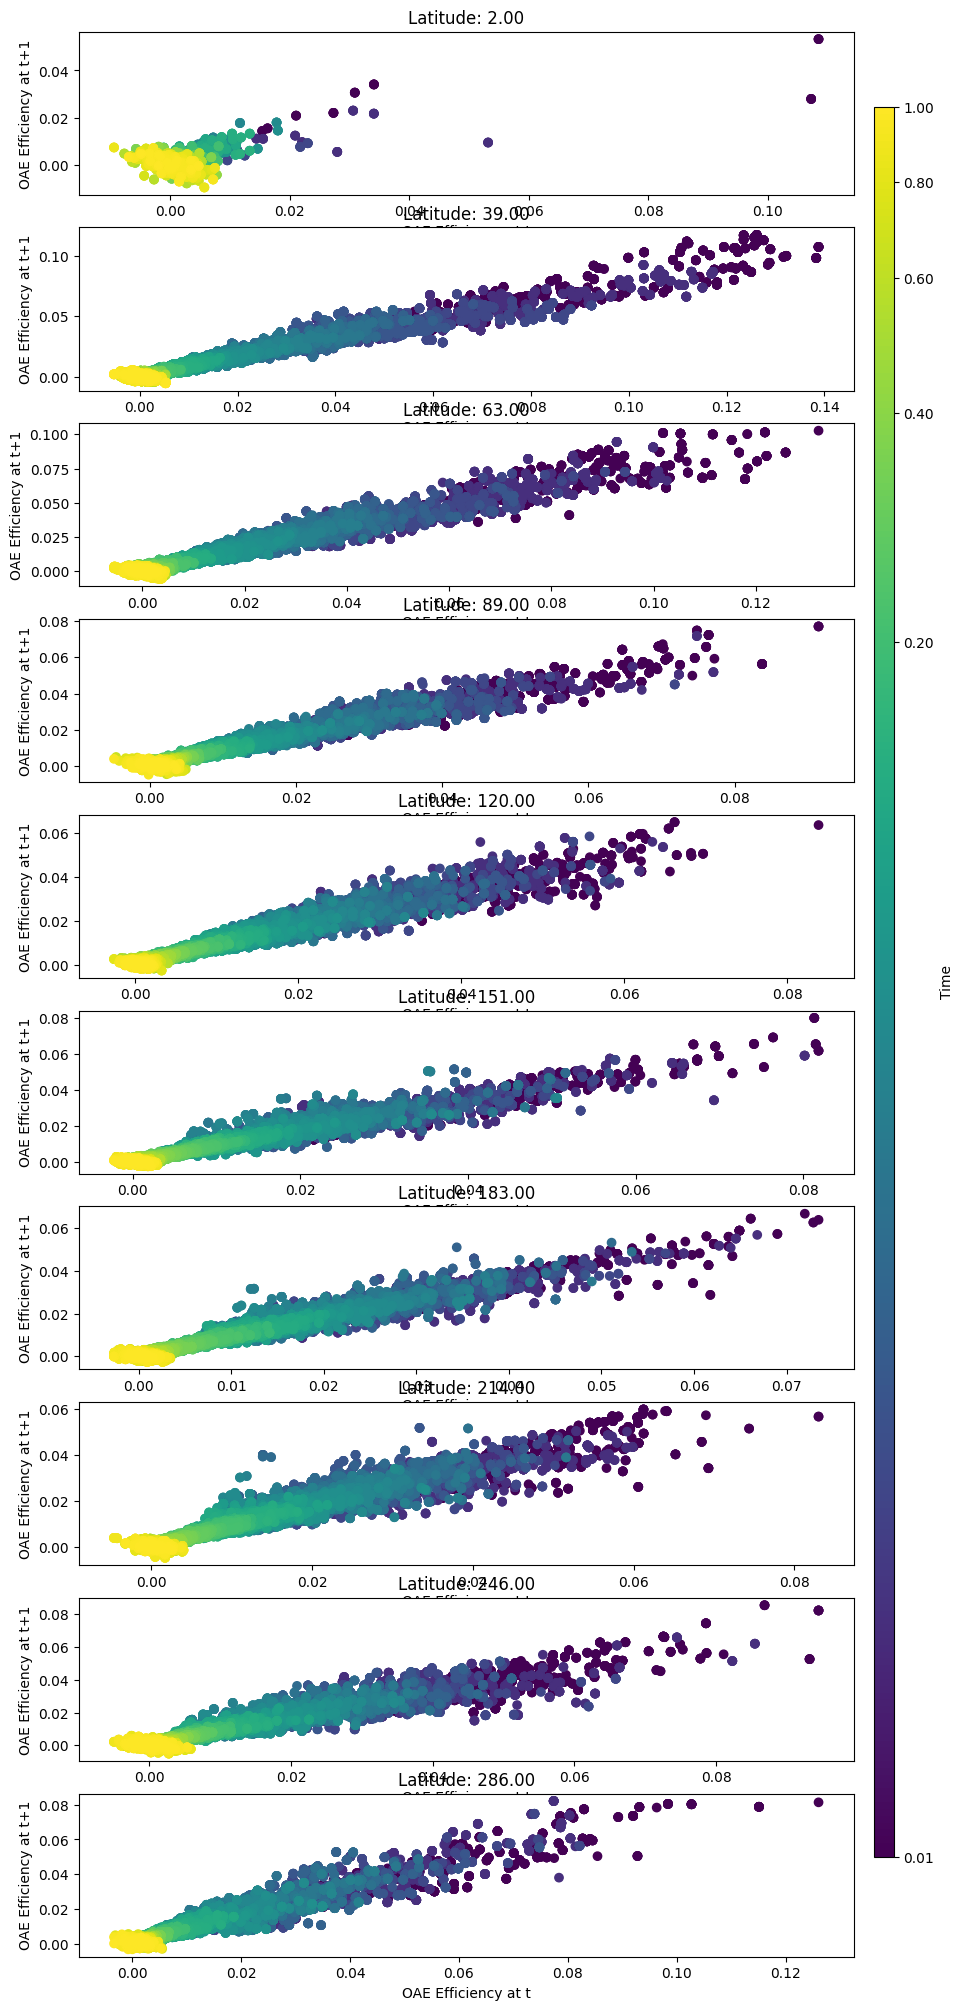

In [78]:
from matplotlib.ticker import FuncFormatter

# Assuming 'time' is strictly positive
norm = mcolors.Normalize(vmin=np.log(time.min()), vmax=np.log(time.max()))
cmap = plt.cm.viridis

fig, ax = plt.subplots(lat_bucket_num, 1, figsize=(10, 25))

for i, lat_bucket in enumerate(lat_buckets):
    lat = lat_bucket[0]
    mask = (latitude == lat) & finite_mask
    colors = cmap(norm(np.log(time[mask])))  # colors mapped by log(time)
    ax[i].scatter(X_t0[mask], X_t1[mask], color=colors)
    ax[i].set_title(f"Latitude: {lat:.2f}")
    ax[i].set_xlabel("OAE Efficiency at t")
    ax[i].set_ylabel("OAE Efficiency at t+1")

# Create a ScalarMappable for the colorbar with the same cmap and norm
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax, label="Time")

# Custom ticks: linear spaced in original time scale, converted to log space for colorbar position
time_ticks = np.linspace(time.min(), time.max(), 6)
log_ticks = np.log(time_ticks)

cbar.set_ticks(log_ticks)

# Format ticks to show linear time values (not log)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{np.exp(x):.2f}"))

plt.show()

In [94]:
# Fit ar model using scipy curve_fit
def ar_model(
        X: np.ndarray,
        a: float,
        b: float,
        c: float,
    ) -> np.ndarray:
    return a / (1 + np.exp(b*(X[:, 0] + c))) * X[:, 1]

unique_latitude = np.unique(latitude)
optimal_params = np.zeros((len(unique_latitude), 3))
r_sq = np.zeros(len(unique_latitude))
popt = [1, 1, -0.5]
for i, lat in enumerate(unique_latitude):
    print(f"Fitting for latitude = {lat:.2f}")
    mask = (latitude == lat) & finite_mask
    # Fit the model to the data
    popt, pcov = curve_fit(
        ar_model,
        np.column_stack((time[mask], X_t0[mask])),
        X_t1[mask],
        p0=popt,
        bounds=(
            [0, 0, -5],
            [1.5, 1e5, 0],
        ),
    )
    optimal_params[i] = popt
    residuals = X_t1[mask] - ar_model(np.column_stack((time[mask], X_t0[mask])), *popt)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((X_t1[mask] - np.mean(X_t1[mask]))**2)
    r_sq[i] = 1 - (ss_res / ss_tot)

Fitting for latitude = 2.00
Fitting for latitude = 3.00


C:\Users\junsu\AppData\Local\Temp\ipykernel_644\283852154.py:8: RuntimeWarning: overflow encountered in exp
  return a / (1 + np.exp(b*(X[:, 0] + c))) * X[:, 1]


Fitting for latitude = 4.00
Fitting for latitude = 5.00
Fitting for latitude = 6.00
Fitting for latitude = 7.00
Fitting for latitude = 8.00
Fitting for latitude = 9.00
Fitting for latitude = 10.00
Fitting for latitude = 11.00
Fitting for latitude = 12.00
Fitting for latitude = 13.00
Fitting for latitude = 14.00
Fitting for latitude = 15.00
Fitting for latitude = 16.00
Fitting for latitude = 17.00
Fitting for latitude = 18.00
Fitting for latitude = 19.00
Fitting for latitude = 20.00
Fitting for latitude = 21.00
Fitting for latitude = 22.00
Fitting for latitude = 23.00
Fitting for latitude = 24.00
Fitting for latitude = 25.00
Fitting for latitude = 26.00
Fitting for latitude = 27.00
Fitting for latitude = 28.00
Fitting for latitude = 29.00
Fitting for latitude = 30.00
Fitting for latitude = 31.00
Fitting for latitude = 32.00
Fitting for latitude = 33.00
Fitting for latitude = 34.00
Fitting for latitude = 35.00
Fitting for latitude = 36.00
Fitting for latitude = 37.00
Fitting for latitude

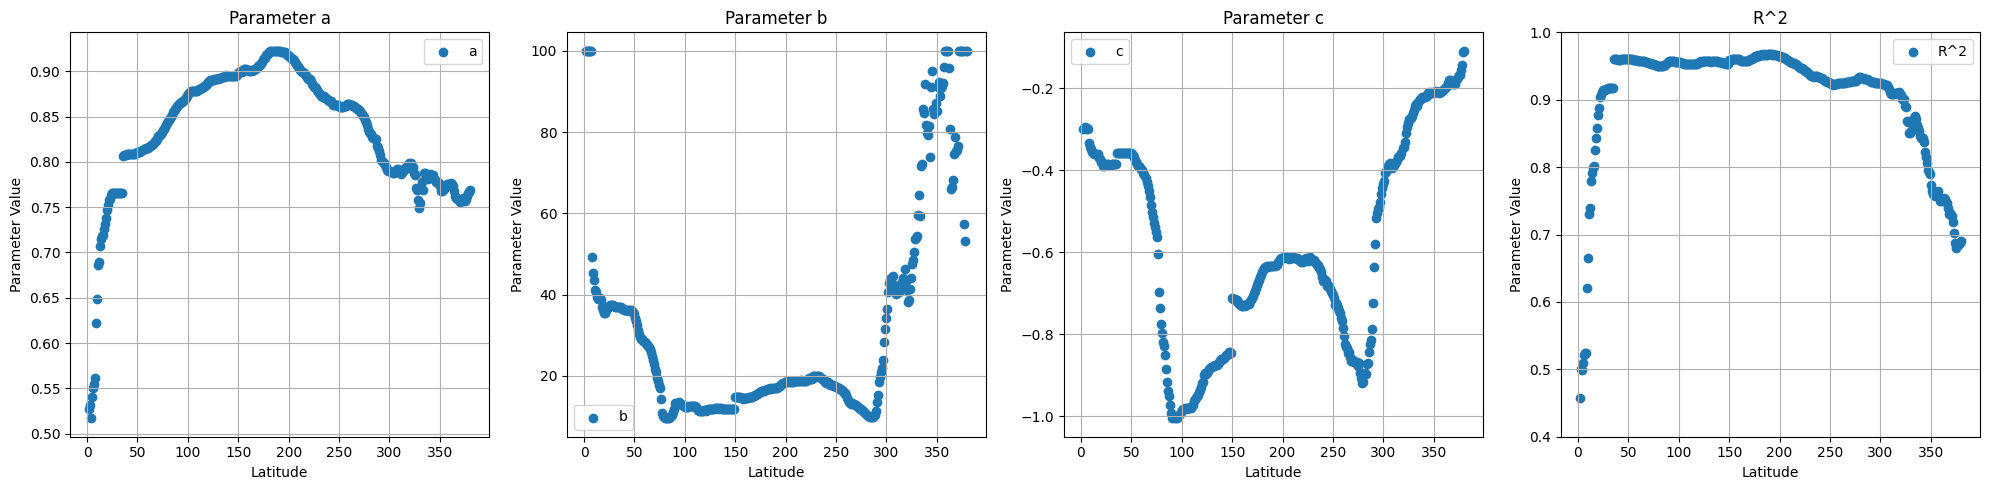

In [92]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].scatter(unique_latitude, optimal_params[:, 0], label="a")
ax[0].set_title("Parameter a")
ax[1].scatter(unique_latitude, optimal_params[:, 1], label="b")
ax[1].set_title("Parameter b")
ax[2].scatter(unique_latitude, optimal_params[:, 2], label="c")
ax[2].set_title("Parameter c")
ax[3].scatter(unique_latitude, r_sq, label="R^2")
ax[3].set_title("R^2")
ax[3].set_ylim(0.4, 1)
for i in range(4):
    ax[i].set_xlabel("Latitude")
    ax[i].set_ylabel("Parameter Value")
    ax[i].grid(True)
    ax[i].legend()
plt.tight_layout()
plt.show()

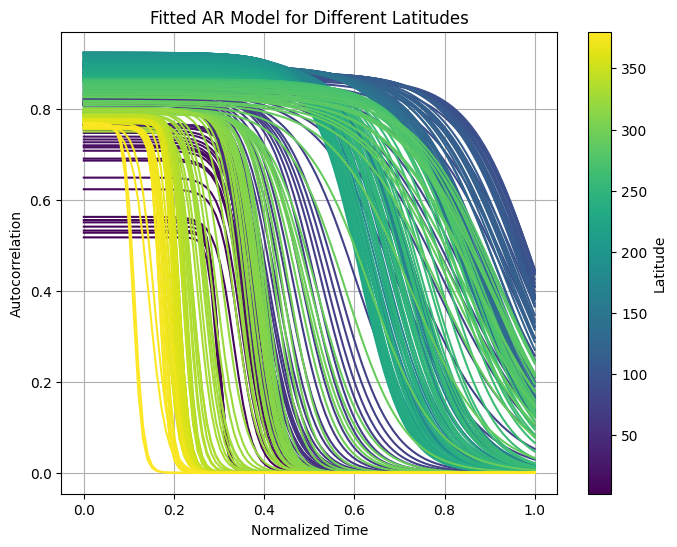

In [93]:
time_x = np.linspace(0, 1, 100)

# Normalize latitudes for colormap
norm = mcolors.Normalize(vmin=unique_latitude.min(), vmax=unique_latitude.max())

fig, ax = plt.subplots(figsize=(8,6))

for i, lat in enumerate(unique_latitude):
    color = cmap(norm(lat))
    y = optimal_params[i, 0] / (1 + np.exp(optimal_params[i, 1] * (time_x + optimal_params[i, 2])))
    ax.plot(time_x, y, color=color, label=f'{lat:.2f}')  # label optional

ax.set_title("Fitted AR Model for Different Latitudes")
ax.set_xlabel("Normalized Time")
ax.set_ylabel("Autocorrelation")
ax.grid(True)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Latitude")

plt.show()